# Training Model using CNN only with out Transfer learning

## Convolutional Neural Network

A **Convolutional Neural Network (CNN)** is a type of deep learning model designed primarily for processing data that has a grid-like structure, especially images. CNNs are widely used in:

* Image classification
* Object detection
* Face recognition
* Medical imaging
* Video analysis
* Self-driving cars

CNNs are inspired by how the human visual cortex processes visual information.

**Why CNNs Were Created**

Traditional neural networks (fully connected networks) become inefficient for images because images contain huge numbers of pixels.

Example:

A color image of size **256 × 256 × 3** contains:

$$
256 \times 256 \times 3 = 196,608
$$

input values.

Connecting every pixel to every neuron would create millions of parameters.

CNNs solve this problem by:

* Sharing weights
* Detecting local patterns
* Preserving spatial relationships

CNNs automatically learn:

* edges
* corners
* textures
* shapes
* objects

in hierarchical layers.

For example:

| Layer         | Learns               |
| ------------- | -------------------- |
| Early layers  | edges, lines         |
| Middle layers | textures, shapes     |
| Deep layers   | faces, cars, animals |

### Main Components of CNN

A CNN mainly contains:

1. Convolution Layer
2. Activation Function
3. Pooling Layer
4. Fully Connected Layer
5. Output Layer

```
Image
  ↓
Convolution
  ↓
Activation Function (ReLU)
  ↓
Pooling
  ↓
Convolution
  ↓
Activation Function (ReLU)
  ↓
Pooling
  ↓
Flatten
  ↓
Fully Connected
  ↓
Output
```

### Convolution Layer

The convolution layer extracts features from images using a small matrix called a **filter/kernel**.

Example kernel:

$$
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$

This kernel detects vertical edges.

#### How Convolution Works

Suppose we have an image:

$$
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 \\
0 & 1 & 1 & 1 & 0 \\
0 & 0 & 1 & 1 & 1 \\
0 & 0 & 1 & 1 & 0 \\
0 & 1 & 1 & 0 & 0
\end{bmatrix}
$$

Kernel:

$$
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
$$

The kernel slides over the image.

At each position:

* Multiply corresponding values
* Sum them
* Produce one output value

This produces a **feature map**.

[Learn More About Convolution](https://masum184e.github.io/handbook/docs/final-semester/Patter%20Recognition/Chapter%203)

### Activation Function (ReLU)

CNN usually applies **ReLU** (Rectified Linear Unit).

* Faster training
* Reduces vanishing gradient problem
* Adds non-linearity

### Pooling Layer

Pooling reduces image size while keeping important information.

Benefits:

* Reduces computation
* Prevents overfitting
* Makes detection robust

#### Max Pooling

$$
\begin{bmatrix}
1 & 3 & 2 & 1 \\
4 & 6 & 5 & 2 \\
7 & 2 & 8 & 3 \\
1 & 5 & 2 & 0
\end{bmatrix}
$$

Using 2×2 max pooling:

* First block max = 6
* Second block max = 5
* Third block max = 7
* Fourth block max = 8

Output:

$$
\begin{bmatrix}
6 & 5 \\
7 & 8
\end{bmatrix}
$$

#### Average Pooling

Using 2×2 average pooling:

* First block average = 3.5
* Second block average = 2.5
* Third block max = 3.75
* Fourth block max = 3.25

Output:

$$
\begin{bmatrix}
3.5 & 2.55 \\
3.75 & 3.25
\end{bmatrix}
$$

### Fully Connected Layer

After several convolution and pooling layers:

* Feature maps are flattened into vectors
* Sent to fully connected layers

These layers perform final classification.

![CNN Architecture](https://raw.githubusercontent.com/masum184e/handbook-old/removed/images/cnn/cnn.png)
image source: https://raw.githubusercontent.com/masum184e/handbook-old/removed/images/cnn/cnn.png


## Importing Libraries

In [30]:
import tensorflow as tf
import keras
from keras import layers
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

## Load the Dataset

In [31]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [32]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test:  {x_test.shape}")
print(f"Shape of y_test:  {y_test.shape}")

Shape of x_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 1)
Shape of x_test:  (10000, 32, 32, 3)
Shape of y_test:  (10000, 1)


## Normalize Image Data

In [ ]:
x_train = x_train.astype("float32") / 255.0   # scales all pixel values to the range [0.0, 1.0]
x_test = x_test.astype("float32") / 255.0

[8]


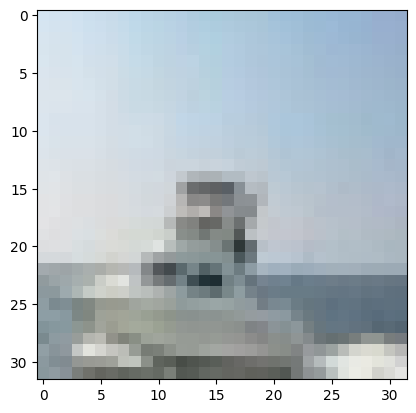

In [ ]:
plt.imshow(x_train[100])
plt.show()
print(y_train[100])

## One-Hot Encode

In [ ]:
num_classes = len(np.unique(y_train))  

# Convert labels to one-hot encoding
# Example: class 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = to_categorical(y_train, num_classes)  # Convert training labels to one-hot vectors
y_test = to_categorical(y_test, num_classes)    # Convert test labels to one-hot vectors

## Prepare The Model

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 1st Convolution block: learns low-level features (edges, lines)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # 2nd Convolution block: learns mid-level features (textures, shapes)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    
    # Flatten 2D feature maps into 1D feature vector
    layers.Flatten(),
    
    # Fully connected layer for decision making
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax'),
])

In [ ]:
model.summary()  # Model architecture and parameter count


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,666 (1.31 MB)

 Trainable params: 342,666 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
) # categorical_crossentropy is used for multiclass classification -> [0, 9]

## Train the model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=64,           # Process 64 samples at a time before updating weights
    epochs=3,                # Train for 3 complete passes through the dataset
    validation_split=0.1,    # Use 10% of training data (5000 samples) to validate during training
)
# Returns training history with loss and accuracy metrics for each epoch

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 125ms/step - accuracy: 0.4322 - loss: 1.5556 - val_accuracy: 0.5324 - val_loss: 1.3323
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.5805 - loss: 1.1837 - val_accuracy: 0.6118 - val_loss: 1.0928
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.6371 - loss: 1.0247 - val_accuracy: 0.6522 - val_loss: 0.9823


In [ ]:
model.evaluate(x_test, y_test)  # Evaluate the performance using 

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6437 - loss: 1.0184


[1.0184004306793213, 0.6437000036239624]

## Visualization

In [42]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


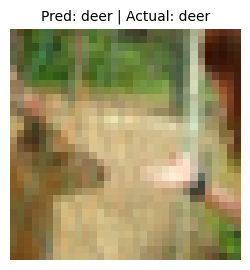

In [43]:
import random

idx = random.randint(0, len(x_test) - 1)

prediction_probabilities = model.predict(x_test[idx:idx+1])

predicted_class_idx = np.argmax(prediction_probabilities)
actual_class_idx = np.argmax(y_test[idx])

predicted_label = class_names[predicted_class_idx]
actual_label = class_names[actual_class_idx]

plt.figure(figsize=(3, 3))
plt.imshow(x_test[idx])
plt.title(f"Pred: {predicted_label} | Actual: {actual_label}", fontsize=10)
plt.axis("off")
plt.show()

## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


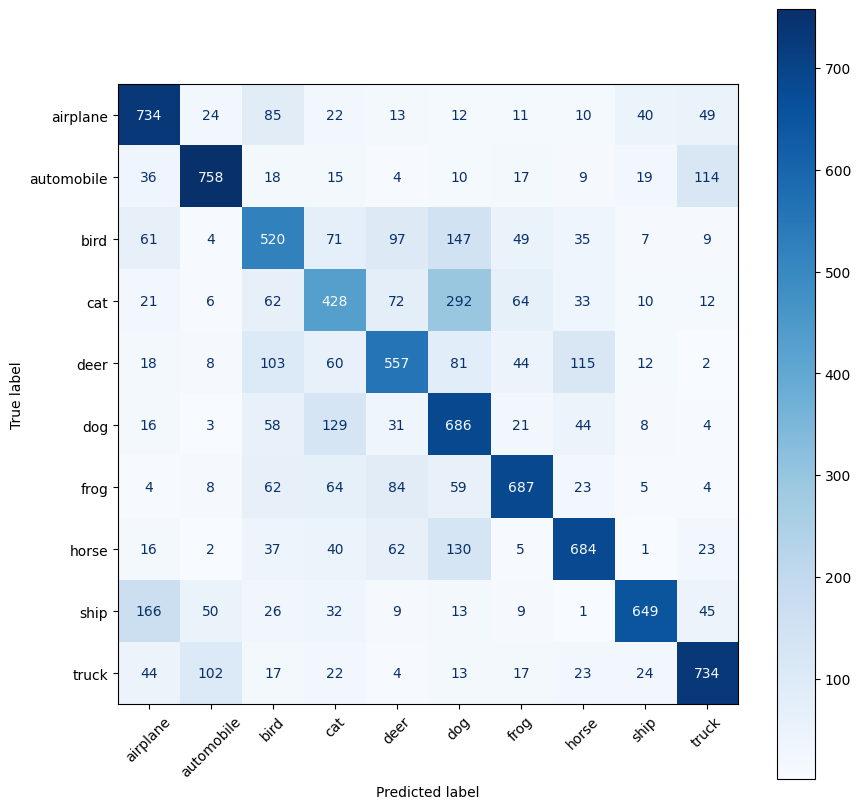

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Tools for computing and plotting confusion matrix

y_pred = model.predict(x_test)  # Model predictions for all test images

y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predicted probabilities to class labels
y_true = np.argmax(y_test, axis=1)          # Convert one-hot test labels back to class indices

cm = confusion_matrix(y_true, y_pred_classes)  # Compute confusion matrix
# Create a visual display of the confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))  # Plot size for readability
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.xticks(rotation=45)  # Rotate x labels so class names are easier to read
plt.show()

## Saving the model

In [ ]:
model.save('outputs/baseline_model.keras')
